In [2]:
!pip install torch torchvision torchaudio
!pip install optuna
!pip install scikit-learn
!pip install matplotlib seaborn

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached colorlog-6.12.0-py3-none-any.whl.metadata (11 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 4.2 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.1 MB 3.3 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.0 MB/s  0:00:00
Using cached colorlog-6.12.0-py3-none-any.whl (12 kB)

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ -

In [1]:
#Import Libraries
import copy
import optuna
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

import os
import copy
os.makedirs("checkpoints", exist_ok=True)

d:\Conda\envs\DL\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
#Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
#Download Dataset
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [4]:
#Custom Dataset
class CustomMNIST(Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image, label = self.dataset[index]

        return image, label

In [5]:
#create dataset 
custom_train = CustomMNIST(train_dataset)
custom_test = CustomMNIST(test_dataset)

In [6]:
#Train Validation Split
train_size = int(0.8 * len(custom_train))
val_size = len(custom_train) - train_size

train_data, val_data = random_split(
    custom_train,
    [train_size, val_size]
)

print(len(train_data))
print(len(val_data))

48000
12000


In [7]:
# DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    custom_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

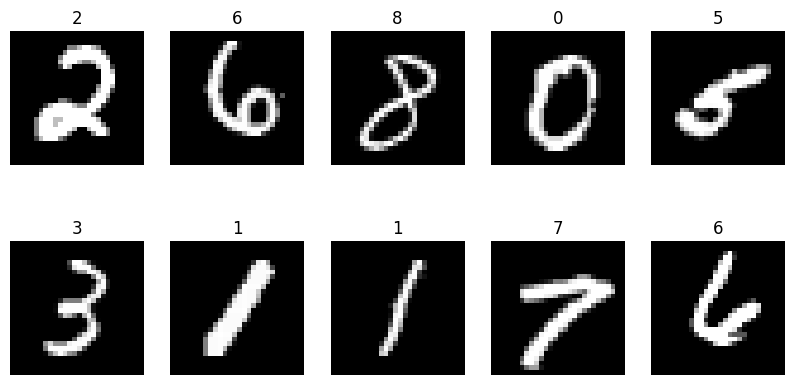

In [8]:
#Visualize Dataset
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(labels[i].item())

    plt.axis("off")

plt.show()

In [9]:
#Model
class MNISTModel(nn.Module):

    def __init__(self,
                 hidden1,
                 hidden2,
                 dropout):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2,10)

        )

    def forward(self,x):

        return self.network(x)

In [10]:
def train_model(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=15,
    trial_number=None
):

    best_loss = np.inf
    patience = 5
    trigger = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=torch.cuda.is_available()
    )

    for epoch in range(epochs):

        ##############################
        # TRAINING
        ##############################

        model.train()

        train_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

        train_accuracy = correct / total
        train_loss /= len(train_loader)

        ##############################
        # VALIDATION
        ##############################

        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                with torch.amp.autocast(
                    device_type="cuda",
                    enabled=torch.cuda.is_available()
                ):

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, pred = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (pred == labels).sum().item()

        val_accuracy = correct / total
        val_loss /= len(val_loader)

        ##############################
        # STORE HISTORY
        ##############################

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_accuracy)
        history["val_acc"].append(val_accuracy)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

        ####################################################
        # SAVE CHECKPOINT AFTER EVERY EPOCH
        ####################################################

        checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_accuracy": train_accuracy,
            "val_accuracy": val_accuracy,
        }

        if trial_number is None:
            checkpoint_path = f"checkpoints/mnist_epoch_{epoch+1}.pth"
        else:
            checkpoint_path = (
                f"checkpoints/trial_{trial_number}_epoch_{epoch+1}.pth"
            )

        torch.save(checkpoint, checkpoint_path)

        print(f"Checkpoint Saved -> {checkpoint_path}")

        ####################################################
        # SAVE BEST MODEL
        ####################################################

        if val_loss < best_loss:

            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())

            if trial_number is None:
                best_model_path = "best_model.pth"
            else:
                best_model_path = (
                    f"checkpoints/best_model_trial_{trial_number}.pth"
                )

            torch.save(best_weights, best_model_path)

            print(f"Best Model Saved -> {best_model_path}")

            trigger = 0

        else:

            trigger += 1

            if trigger >= patience:

                print("\nEarly Stopping Triggered!")
                break

    ##############################
    # LOAD BEST MODEL
    ##############################

    model.load_state_dict(best_weights)

    if torch.cuda.is_available():

        print("\nGPU Memory Usage")
        print(f"Allocated : {torch.cuda.memory_allocated()/1024**2:.2f} MB")
        print(f"Reserved  : {torch.cuda.memory_reserved()/1024**2:.2f} MB")

    return model, history

In [11]:
# Optuna Objective Function
def objective(trial):

    # Hyperparameters
    hidden1 = trial.suggest_int("hidden1", 128, 512)
    hidden2 = trial.suggest_int("hidden2", 64, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    lr = trial.suggest_float(
        "lr",
        1e-4,
        1e-2,
        log=True
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "AdamW", "RMSprop"]
    )

    # Create Model
    model = MNISTModel(
        hidden1,
        hidden2,
        dropout
    ).to(device)

    # Loss Function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    if optimizer_name == "Adam":

        optimizer = optim.Adam(
            model.parameters(),
            lr=lr
        )

    elif optimizer_name == "AdamW":

        optimizer = optim.AdamW(
            model.parameters(),
            lr=lr
        )

    else:

        optimizer = optim.RMSprop(
            model.parameters(),
            lr=lr
        )

    # Train Model
    model, history = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=8,
        trial_number=trial.number     # <-- Added
    )

    # Return Best Validation Accuracy
    return max(history["val_acc"])

In [12]:
#Run Optuna
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=20
)

[I 2026-07-25 18:12:31,377] A new study created in memory with name: no-name-d70296f3-5acc-4daf-9d5b-e422ce245e51


Epoch [1/8] | Train Loss: 0.6377 | Train Acc: 0.8273 | Val Loss: 0.3032 | Val Acc: 0.9101
Checkpoint Saved -> checkpoints/trial_0_epoch_1.pth
Best Model Saved -> checkpoints/best_model_trial_0.pth
Epoch [2/8] | Train Loss: 0.2793 | Train Acc: 0.9177 | Val Loss: 0.2308 | Val Acc: 0.9317
Checkpoint Saved -> checkpoints/trial_0_epoch_2.pth
Best Model Saved -> checkpoints/best_model_trial_0.pth
Epoch [3/8] | Train Loss: 0.2162 | Train Acc: 0.9368 | Val Loss: 0.1914 | Val Acc: 0.9437
Checkpoint Saved -> checkpoints/trial_0_epoch_3.pth
Best Model Saved -> checkpoints/best_model_trial_0.pth
Epoch [4/8] | Train Loss: 0.1821 | Train Acc: 0.9462 | Val Loss: 0.1693 | Val Acc: 0.9490
Checkpoint Saved -> checkpoints/trial_0_epoch_4.pth
Best Model Saved -> checkpoints/best_model_trial_0.pth
Epoch [5/8] | Train Loss: 0.1556 | Train Acc: 0.9533 | Val Loss: 0.1476 | Val Acc: 0.9533
Checkpoint Saved -> checkpoints/trial_0_epoch_5.pth
Best Model Saved -> checkpoints/best_model_trial_0.pth
Epoch [6/8] | T

[I 2026-07-25 18:15:45,176] Trial 0 finished with value: 0.9663333333333334 and parameters: {'hidden1': 158, 'hidden2': 212, 'dropout': 0.11969912407429502, 'lr': 0.00010526590878440145, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.9663333333333334.


Epoch [8/8] | Train Loss: 0.1085 | Train Acc: 0.9681 | Val Loss: 0.1100 | Val Acc: 0.9663
Checkpoint Saved -> checkpoints/trial_0_epoch_8.pth
Best Model Saved -> checkpoints/best_model_trial_0.pth

GPU Memory Usage
Allocated : 20.41 MB
Reserved  : 26.00 MB
Epoch [1/8] | Train Loss: 0.3598 | Train Acc: 0.9049 | Val Loss: 0.1677 | Val Acc: 0.9486
Checkpoint Saved -> checkpoints/trial_1_epoch_1.pth
Best Model Saved -> checkpoints/best_model_trial_1.pth
Epoch [2/8] | Train Loss: 0.1603 | Train Acc: 0.9534 | Val Loss: 0.1189 | Val Acc: 0.9632
Checkpoint Saved -> checkpoints/trial_1_epoch_2.pth
Best Model Saved -> checkpoints/best_model_trial_1.pth
Epoch [3/8] | Train Loss: 0.1299 | Train Acc: 0.9616 | Val Loss: 0.1224 | Val Acc: 0.9657
Checkpoint Saved -> checkpoints/trial_1_epoch_3.pth
Epoch [4/8] | Train Loss: 0.1144 | Train Acc: 0.9660 | Val Loss: 0.1104 | Val Acc: 0.9692
Checkpoint Saved -> checkpoints/trial_1_epoch_4.pth
Best Model Saved -> checkpoints/best_model_trial_1.pth
Epoch [5/8

[I 2026-07-25 18:17:51,432] Trial 1 finished with value: 0.97475 and parameters: {'hidden1': 187, 'hidden2': 82, 'dropout': 0.13637180369814883, 'lr': 0.002116697222072881, 'optimizer': 'RMSprop'}. Best is trial 1 with value: 0.97475.


...

Epoch [8/8] | Train Loss: 0.0596 | Train Acc: 0.9814 | Val Loss: 0.0771 | Val Acc: 0.9767
Checkpoint Saved -> checkpoints/trial_17_epoch_8.pth

GPU Memory Usage
Allocated : 25.89 MB
Reserved  : 50.00 MB
Epoch [1/8] | Train Loss: 0.4561 | Train Acc: 0.8708 | Val Loss: 0.2215 | Val Acc: 0.9348
Checkpoint Saved -> checkpoints/trial_18_epoch_1.pth
Best Model Saved -> checkpoints/best_model_trial_18.pth
Epoch [2/8] | Train Loss: 0.1929 | Train Acc: 0.9425 | Val Loss: 0.1469 | Val Acc: 0.9545
Checkpoint Saved -> checkpoints/trial_18_epoch_2.pth
Best Model Saved -> checkpoints/best_model_trial_18.pth
Epoch [3/8] | Train Loss: 0.1391 | Train Acc: 0.9579 | Val Loss: 0.1169 | Val Acc: 0.9632
Checkpoint Saved -> checkpoints/trial_18_epoch_3.pth
Best Model Saved -> checkpoints/best_model_trial_18.pth
Epoch [4/8] | Train Loss: 0.1114 | Train Acc: 0.9668 | Val Loss: 0.1025 | Val Acc: 0.9683
Checkpoint Saved -> checkpoints/trial_18_epoch_4.pth
Best Model Saved -> checkpoints/best_model_trial_18.pth
E

[I 2026-07-25 19:00:41,265] Trial 18 finished with value: 0.9763333333333334 and parameters: {'hidden1': 339, 'hidden2': 158, 'dropout': 0.18097374287567233, 'lr': 0.000206318334034815, 'optimizer': 'Adam'}. Best is trial 15 with value: 0.97925.


Epoch [8/8] | Train Loss: 0.0546 | Train Acc: 0.9830 | Val Loss: 0.0771 | Val Acc: 0.9758
Checkpoint Saved -> checkpoints/trial_18_epoch_8.pth

GPU Memory Usage
Allocated : 24.20 MB
Reserved  : 50.00 MB
Epoch [1/8] | Train Loss: 0.3913 | Train Acc: 0.8833 | Val Loss: 0.1871 | Val Acc: 0.9428
Checkpoint Saved -> checkpoints/trial_19_epoch_1.pth
Best Model Saved -> checkpoints/best_model_trial_19.pth
Epoch [2/8] | Train Loss: 0.1739 | Train Acc: 0.9484 | Val Loss: 0.1195 | Val Acc: 0.9630
Checkpoint Saved -> checkpoints/trial_19_epoch_2.pth
Best Model Saved -> checkpoints/best_model_trial_19.pth
Epoch [3/8] | Train Loss: 0.1270 | Train Acc: 0.9620 | Val Loss: 0.1021 | Val Acc: 0.9680
Checkpoint Saved -> checkpoints/trial_19_epoch_3.pth
Best Model Saved -> checkpoints/best_model_trial_19.pth
Epoch [4/8] | Train Loss: 0.1017 | Train Acc: 0.9695 | Val Loss: 0.0886 | Val Acc: 0.9725
Checkpoint Saved -> checkpoints/trial_19_epoch_4.pth
Best Model Saved -> checkpoints/best_model_trial_19.pth
E

[I 2026-07-25 19:03:17,631] Trial 19 finished with value: 0.9776666666666667 and parameters: {'hidden1': 447, 'hidden2': 107, 'dropout': 0.32258806040395505, 'lr': 0.00042720295442840426, 'optimizer': 'Adam'}. Best is trial 15 with value: 0.97925.


Epoch [8/8] | Train Loss: 0.0586 | Train Acc: 0.9811 | Val Loss: 0.0775 | Val Acc: 0.9765
Checkpoint Saved -> checkpoints/trial_19_epoch_8.pth

GPU Memory Usage
Allocated : 24.98 MB
Reserved  : 50.00 MB


In [13]:
#Best Parameters
print(study.best_trial.value)

print(study.best_trial.params)


0.97925
{'hidden1': 406, 'hidden2': 256, 'dropout': 0.19970773692612215, 'lr': 0.0003240828586551443, 'optimizer': 'Adam'}


In [14]:
#Train Final Model
params = study.best_trial.params

model = MNISTModel(
    params["hidden1"],
    params["hidden2"],
    params["dropout"]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_name = params["optimizer"]

if optimizer_name=="Adam":

    optimizer = optim.Adam(
        model.parameters(),
        lr=params["lr"]
    )

elif optimizer_name=="AdamW":

    optimizer = optim.AdamW(
        model.parameters(),
        lr=params["lr"]
    )

else:

    optimizer = optim.RMSprop(
        model.parameters(),
        lr=params["lr"]
    )

model,history = train_model(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=20
)

Epoch [1/20] | Train Loss: 0.3493 | Train Acc: 0.8978 | Val Loss: 0.1660 | Val Acc: 0.9474
Checkpoint Saved -> checkpoints/mnist_epoch_1.pth
Best Model Saved -> best_model.pth
Epoch [2/20] | Train Loss: 0.1436 | Train Acc: 0.9577 | Val Loss: 0.1101 | Val Acc: 0.9643
Checkpoint Saved -> checkpoints/mnist_epoch_2.pth
Best Model Saved -> best_model.pth
Epoch [3/20] | Train Loss: 0.1013 | Train Acc: 0.9691 | Val Loss: 0.1004 | Val Acc: 0.9688
Checkpoint Saved -> checkpoints/mnist_epoch_3.pth
Best Model Saved -> best_model.pth
Epoch [4/20] | Train Loss: 0.0800 | Train Acc: 0.9755 | Val Loss: 0.0849 | Val Acc: 0.9723
Checkpoint Saved -> checkpoints/mnist_epoch_4.pth
Best Model Saved -> best_model.pth
Epoch [5/20] | Train Loss: 0.0636 | Train Acc: 0.9800 | Val Loss: 0.0760 | Val Acc: 0.9752
Checkpoint Saved -> checkpoints/mnist_epoch_5.pth
Best Model Saved -> best_model.pth
Epoch [6/20] | Train Loss: 0.0522 | Train Acc: 0.9826 | Val Loss: 0.0765 | Val Acc: 0.9763
Checkpoint Saved -> checkpoin

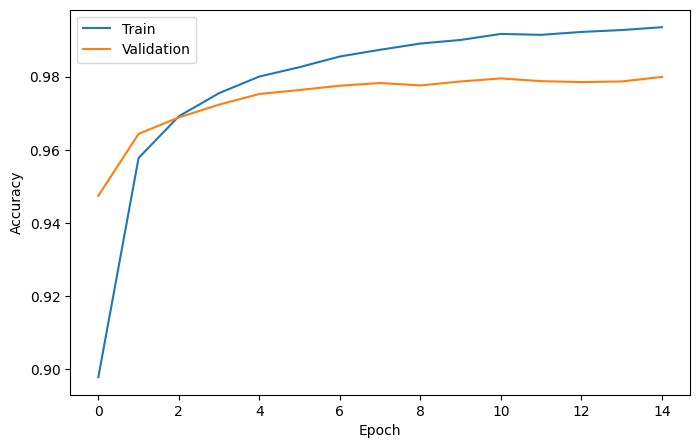

In [15]:
#Plot Accuracy
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"],label="Train")

plt.plot(history["val_acc"],label="Validation")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

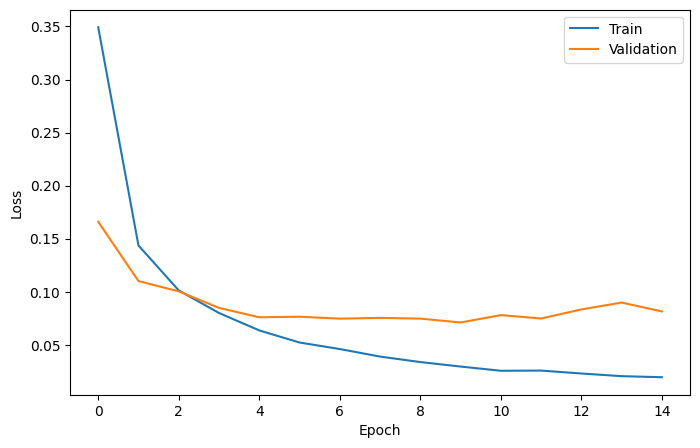

In [16]:
#Plot Loss
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"],label="Train")

plt.plot(history["val_loss"],label="Validation")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [17]:
#Test Accuracy
model.eval()

correct = 0

total = 0

predictions = []

targets = []

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _,pred = torch.max(outputs,1)

        predictions.extend(pred.cpu().numpy())

        targets.extend(labels.cpu().numpy())

        total += labels.size(0)

        correct += (pred==labels).sum().item()

print("Test Accuracy :",100*correct/total,"%")

Test Accuracy : 98.18 %


In [18]:
#Classification Report
print(
    classification_report(
        targets,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.99      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

